# Food Spoilage Prediction – Machine Learning Project


### Research Question

> **Can machine learning predict whether a food product will spoil using product, storage, handling, demand and supply-chain information?**

### Target Variable

`was_spoiled`

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


# DATA COLLECTION

## 1.1 Import Pandas

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

## 1.2 Load the Dataset

Dataset is from the Kaggle its a synthetic dataset. 


In [46]:
file_path = 'perishable_cleaned.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.3 Check Dataset Size

In [47]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 42


## 1.4 View the First Rows

In [48]:
df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


## 1.5 View All Column Names

In [49]:
print(df.columns.tolist())

['record_id', 'product_id', 'product_name', 'category', 'store_id', 'region', 'supplier_id', 'transaction_date', 'expiration_date', 'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation', 'base_price', 'cost_price', 'initial_quantity', 'spoilage_sensitivity', 'day_of_week', 'is_weekend', 'month', 'daily_demand', 'demand_variability', 'temp_abuse_events', 'distribution_hours', 'handling_score', 'packaging_score', 'spoilage_risk', 'was_spoiled', 'quality_grade', 'days_until_expiry', 'markdown_applied', 'discount_pct', 'selling_price', 'units_sold', 'units_wasted', 'waste_pct', 'revenue', 'waste_cost', 'profit', 'profit_margin_pct', 'supplier_score', 'is_promoted']


## 1.6 Check Data Types

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   100000 non-null  int64  
 1   product_id                  100000 non-null  object 
 2   product_name                100000 non-null  object 
 3   category                    100000 non-null  object 
 4   store_id                    100000 non-null  object 
 5   region                      100000 non-null  object 
 6   supplier_id                 100000 non-null  object 
 7   transaction_date            100000 non-null  object 
 8   expiration_date             100000 non-null  object 
 9   shelf_life_days             100000 non-null  int64  
 10  days_remaining_at_purchase  100000 non-null  int64  
 11  storage_temp                100000 non-null  float64
 12  temp_deviation              100000 non-null  float64
 13  base_price     

## 1.7 Check the Target Variable

Our target is `was_spoiled`.

This is a **binary classification** problem because there are two possible outcomes:

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


In [51]:
print(df['was_spoiled'].value_counts())

was_spoiled
0    80558
1    19442
Name: count, dtype: int64


## 1.8 Initial Feature Selection


### Main features

`category`
`region`
`shelf_life_days`
`days_remaining_at_purchase`
`storage_temp`
`temp_deviation`
`initial_quantity`
`spoilage_sensitivity`
`daily_demand`
`demand_variability`
`temp_abuse_events`
`distribution_hours`
`handling_score`
`packaging_score`
`supplier_score`

### Target

`was_spoiled`


# DATA CLEANING & EDA


## 2.1 Check Missing Values

In [52]:
missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Series([], dtype: int64)

Total missing values: 0


## 2.2 Check Duplicate Rows

In [53]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 2.3 Remove Exact Duplicates

In [54]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (100000, 42)


## 2.4 Basic Statistics

In [55]:
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,67.169300,56.114940,3.127054,1.597402,36.408563,20.05853,254.851800,0.685802,3.001080,...,34.356048,202.835650,52.016150,22.591979,5911.547597,1632.244932,797.837098,13.394057,8.207760,0.148980
std,28867.657797,140.550322,118.160892,9.503199,1.206793,87.424777,48.89381,141.686286,0.215392,2.000745,...,85.381541,138.942464,79.279844,28.717231,19277.611250,8275.432747,11331.288655,46.246729,1.397525,0.356071
min,1.000000,1.000000,0.000000,-27.700000,0.000000,1.000000,0.41000,10.000000,0.300000,0.000000,...,0.260000,0.000000,0.000000,0.000000,0.000000,0.000000,-169495.000000,-1798.800000,6.000000,0.000000
25%,25000.750000,5.000000,4.000000,1.100000,0.600000,6.270000,3.36000,132.000000,0.500000,1.000000,...,5.320000,85.000000,0.000000,0.000000,542.880000,0.000000,-48.460000,0.000000,7.000000,0.000000
50%,50000.500000,9.000000,8.000000,4.000000,1.400000,10.220000,5.58000,255.000000,0.750000,3.000000,...,8.800000,193.000000,15.000000,12.400000,1450.420000,62.505000,276.700000,26.300000,9.000000,0.000000
75%,75000.250000,24.000000,20.000000,6.600000,2.300000,17.010000,9.50000,377.000000,0.900000,5.000000,...,15.450000,309.000000,80.000000,30.800000,3170.720000,431.660000,992.677500,41.100000,9.000000,0.000000
max,100000.000000,730.000000,723.000000,27.700000,9.000000,499.980000,346.61000,500.000000,0.950000,6.000000,...,499.980000,500.000000,500.000000,100.000000,246243.640000,169495.000000,136195.210000,60.300000,10.000000,1.000000


## 2.5 Check the Target Distribution

was_spoiled
0    80558
1    19442
Name: count, dtype: int64


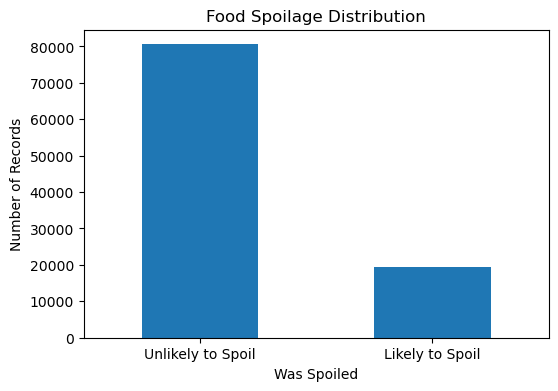

In [56]:
target_counts = df['was_spoiled'].value_counts()

print(target_counts)

target_counts.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Food Spoilage Distribution')
plt.xlabel('Was Spoiled')
plt.ylabel('Number of Records')
plt.xticks([0, 1], ['Unlikely to Spoil', 'Likely to Spoil'], rotation=0)
plt.show()

## 2.6 Target Percentages

In [57]:
target_percent = df['was_spoiled'].value_counts(normalize=True) * 100

print(target_percent)

was_spoiled
0    80.558
1    19.442
Name: proportion, dtype: float64


## 2.7 Explore Storage Temperature

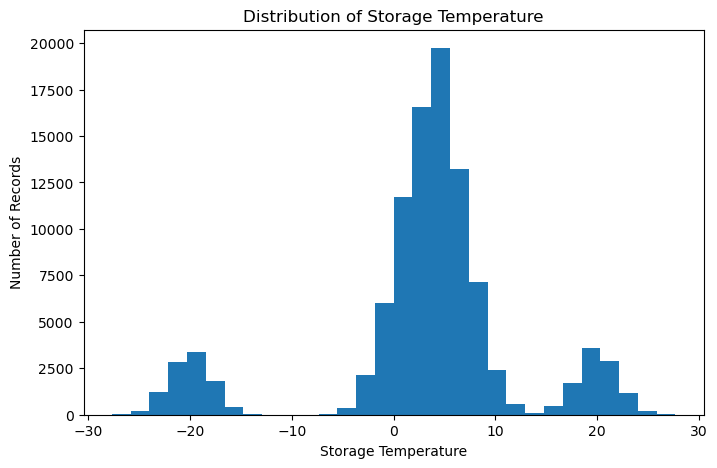

In [58]:
plt.figure(figsize=(8, 5))

plt.hist(df['storage_temp'].dropna(), bins=30)

plt.title('Distribution of Storage Temperature')
plt.xlabel('Storage Temperature')
plt.ylabel('Number of Records')

plt.show()

## 2.8 Explore Shelf Life

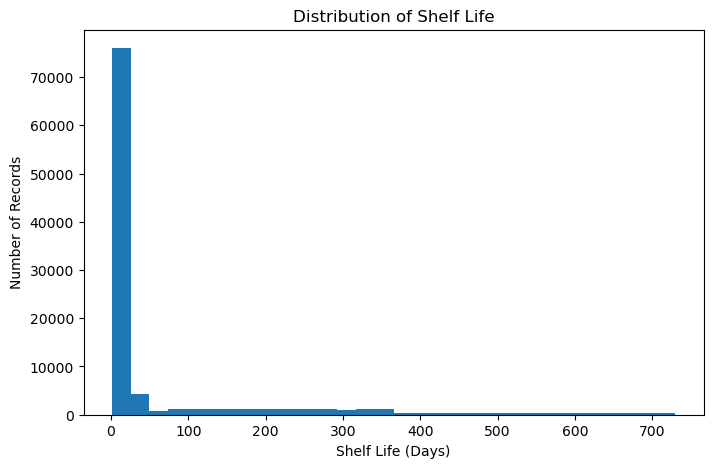

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(df['shelf_life_days'].dropna(), bins=30)

plt.title('Distribution of Shelf Life')
plt.xlabel('Shelf Life (Days)')
plt.ylabel('Number of Records')

plt.show()

## 2.9 Spoilage by Food Category

In [60]:
category_spoilage = pd.crosstab(
    df['category'],
    df['was_spoiled'],
    normalize='index'
) * 100

print(category_spoilage)

was_spoiled              0          1
category                             
Bakery           81.721287  18.278713
Beverages        82.274518  17.725482
Dairy            81.112003  18.887997
Deli             80.582524  19.417476
Frozen_Meals     83.059559  16.940441
Meat             79.045251  20.954749
Pharmaceuticals  79.298419  20.701581
Produce          81.331867  18.668133
Ready_to_Eat     77.888347  22.111653
Seafood          79.331124  20.668876


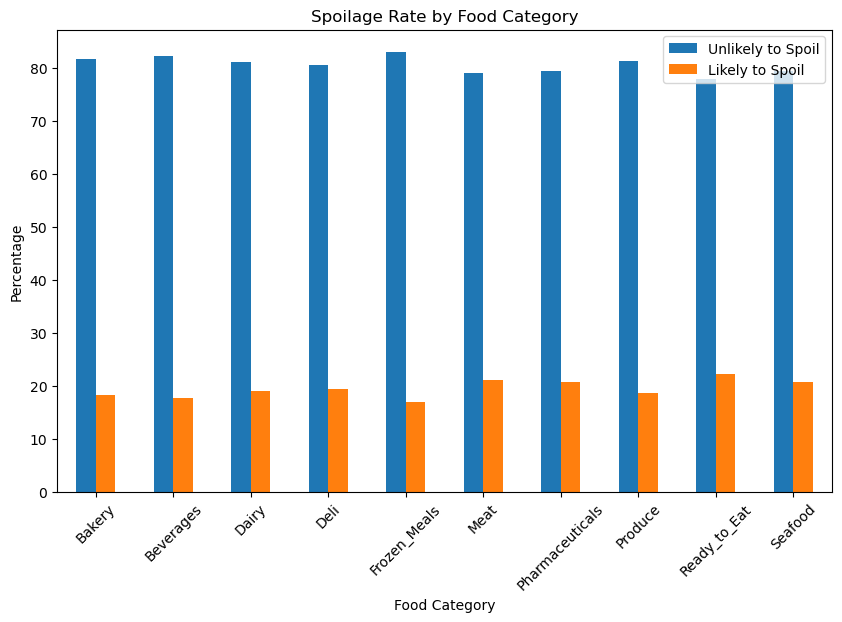

In [61]:
category_spoilage.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Spoilage Rate by Food Category')
plt.xlabel('Food Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Unlikely to Spoil', 'Likely to Spoil'])
plt.show()

## 2.10 Simple Correlation Check


In [62]:
numeric_columns = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'was_spoiled'
]

correlation = df[numeric_columns].corr()

correlation['was_spoiled'].sort_values(ascending=False)

was_spoiled                   1.000000
temp_deviation                0.042662
spoilage_sensitivity          0.036952
distribution_hours            0.028779
temp_abuse_events             0.028669
daily_demand                  0.022651
storage_temp                  0.008591
demand_variability            0.005133
supplier_score                0.002906
shelf_life_days              -0.002219
initial_quantity             -0.003028
days_remaining_at_purchase   -0.003583
handling_score               -0.056309
packaging_score              -0.088480
Name: was_spoiled, dtype: float64

# FEATURE ENGINEERING

## 3.1 Select the Final Features

In [63]:
features = [
    'category',
    'region',
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score'
]

target = 'was_spoiled'

X = df[features].copy()
y = df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (100000, 15)
y shape: (100000,)


## 3.2 Create a Simple Temperature Risk Feature


In [64]:
X['temperature_problem'] = (
    X['temp_deviation'] > 0
).astype(int)

print(X[['temp_deviation', 'temperature_problem']].head())

   temp_deviation  temperature_problem
0             1.0                    1
1             0.3                    1
2             1.3                    1
3             3.0                    1
4             0.5                    1


## 3.3 Create a Simple Demand Pressure Feature


In [65]:
X['inventory_days_estimate'] = (
    X['initial_quantity'] /
    X['daily_demand'].replace(0, np.nan)
)

X['inventory_days_estimate'] = X['inventory_days_estimate'].fillna(0)

print(X[['initial_quantity', 'daily_demand', 'inventory_days_estimate']].head())

   initial_quantity  daily_demand  inventory_days_estimate
0               158            54                 2.925926
1               353            55                 6.418182
2               483           331                 1.459215
3               477             7                68.142857
4               391           169                 2.313609


## 3.4 Update the Numerical Feature List


In [66]:
categorical_features = [
    'category',
    'region'
]

numerical_features = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'temperature_problem',
    'inventory_days_estimate'
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['category', 'region']
Number of numerical features: 15


## 3.5 Check the Final Dataset

In [67]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

X.head()

Final X shape: (100000, 17)
Final y shape: (100000,)


,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,initial_quantity,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,temperature_problem,inventory_days_estimate
0,Bakery,West,4,4,21.0,1.0,158,0.50,54,0.35,0,41.5,9,10,9,1,2.925926
1,Meat,Southwest,9,7,0.7,0.3,353,0.90,55,0.35,0,38.7,8,8,6,1,6.418182
2,Bakery,Midwest,2,2,21.3,1.3,483,0.50,331,0.35,0,54.1,4,8,9,1,1.459215
3,Pharmaceuticals,Midwest,87,80,8.0,3.0,477,0.85,7,0.38,0,70.1,5,9,6,1,68.142857
4,Ready_to_Eat,West,4,3,3.5,0.5,391,0.90,169,0.25,0,64.9,5,6,6,1,2.313609


# MODELING


## 4.1 Import Machine Learning Libraries

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 4.2 Split the Data

- 80% for training
- 20% for testing


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 80000
Testing rows: 20000


## 4.3 Preprocess the Features


In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [71]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

## 4.4 Model 1 – Logistic Regression


In [72]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 4.5 Make Logistic Regression Predictions

In [73]:
logistic_predictions = logistic_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


## 4.6 Model 2 – Random Forest


In [74]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4.7 Make Random Forest Predictions

In [75]:
rf_predictions = random_forest_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


# EVALUATION


## 5.1 Import Evaluation Metrics

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 5.2 Evaluate Logistic Regression

In [77]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=['Not Spoiled', 'Spoiled']
))

Logistic Regression
-------------------
Accuracy : 0.5603
Precision: 0.23617982361798237
Recall   : 0.5648148148148148
F1 Score : 0.3330805399666313

Classification Report:
              precision    recall  f1-score   support

 Not Spoiled       0.84      0.56      0.67     16112
     Spoiled       0.24      0.56      0.33      3888

    accuracy                           0.56     20000
   macro avg       0.54      0.56      0.50     20000
weighted avg       0.72      0.56      0.61     20000



## 5.3 Evaluate Random Forest

In [78]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=['Not Spoiled', 'Spoiled']
))

Random Forest
-------------
Accuracy : 0.80545
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

 Not Spoiled       0.81      1.00      0.89     16112
     Spoiled       0.00      0.00      0.00      3888

    accuracy                           0.81     20000
   macro avg       0.40      0.50      0.45     20000
weighted avg       0.65      0.81      0.72     20000



## 5.4 Compare Both Models

This table makes it easy to identify the better model.

In [79]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall
    ],
    'F1 Score': [
        logistic_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.56030,0.23618,0.564815,0.333081
1,Random Forest,0.80545,0.00000,0.000000,0.000000


## 5.5 Visual Model Comparison

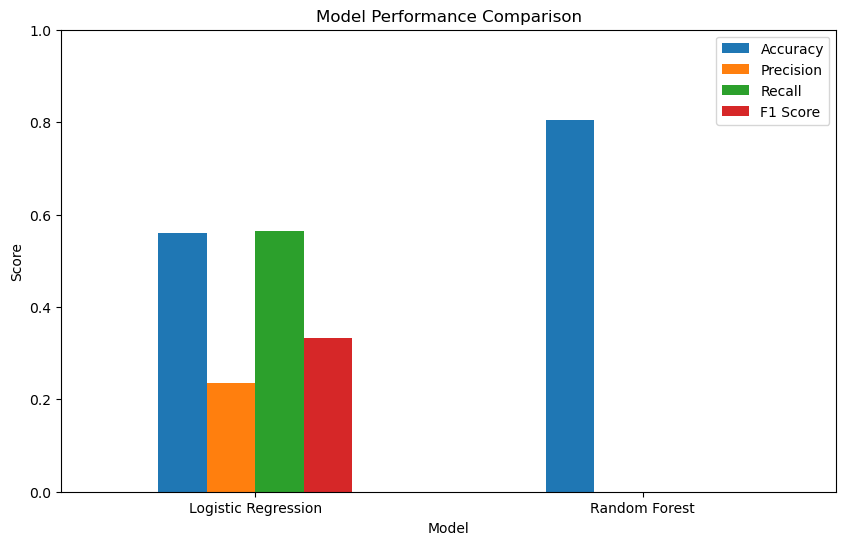

In [80]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 5.6 Confusion Matrix – Random Forest



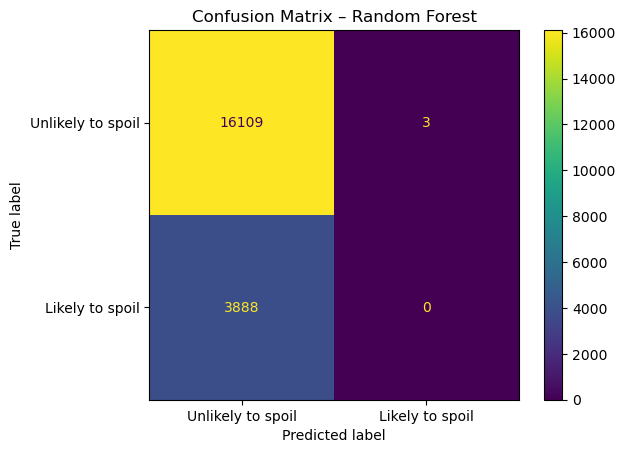

In [81]:
cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Unlikely to spoil', 'Likely to spoil']
)

disp.plot()

plt.title('Confusion Matrix – Random Forest')
plt.show()

## 5.7 Feature Importance



In [82]:
rf_preprocessor = random_forest_model.named_steps['preprocessor']
rf_model = random_forest_model.named_steps['model']

feature_names = rf_preprocessor.get_feature_names_out()
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,numeric__distribution_hours,0.103142
4,numeric__initial_quantity,0.097776
14,numeric__inventory_days_estimate,0.091442
2,numeric__storage_temp,0.085756
7,numeric__demand_variability,0.084716
6,numeric__daily_demand,0.079142
3,numeric__temp_deviation,0.076615
1,numeric__days_remaining_at_purchase,0.062524
0,numeric__shelf_life_days,0.060845
10,numeric__handling_score,0.041310


## 5.8 Plot the Most Important Features

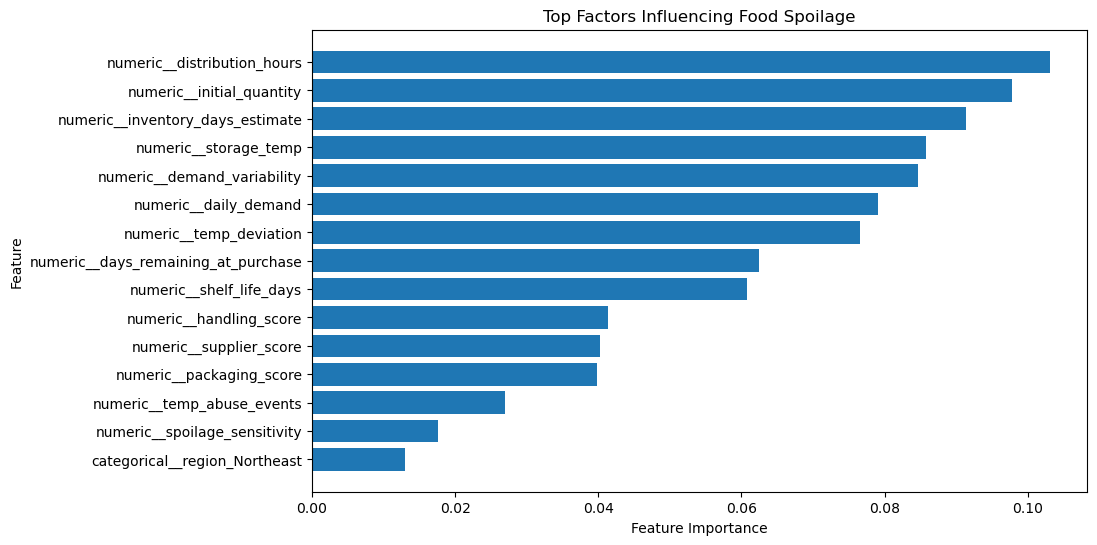

In [83]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top Factors Influencing Food Spoilage')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

## 5.9 Predict a New Food Product


In [84]:
new_food = pd.DataFrame({
    'category': ['Dairy'],
    'region': ['North'],
    'shelf_life_days': [30],
    'days_remaining_at_purchase': [5],
    'storage_temp': [8.0],
    'temp_deviation': [4.0],
    'initial_quantity': [200],
    'spoilage_sensitivity': [0.9],
    'daily_demand': [20],
    'demand_variability': [0.4],
    'temp_abuse_events': [3],
    'distribution_hours': [50],
    'handling_score': [4],
    'packaging_score': [5],
    'supplier_score': [6],
    'temperature_problem': [1],
    'inventory_days_estimate': [10]
})

new_food

,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,initial_quantity,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,temperature_problem,inventory_days_estimate
0,Dairy,North,30,5,8.0,4.0,200,0.9,20,0.4,3,50,4,5,6,1,10


In [85]:
prediction = random_forest_model.predict(new_food)

if prediction[0] == 1:
    print("Prediction: FOOD IS LIKELY TO SPOIL")
else:
    print("Prediction: FOOD IS NOT LIKELY TO SPOIL")

Prediction: FOOD IS NOT LIKELY TO SPOIL


In [86]:
probability = random_forest_model.predict_proba(new_food)

print("Probability of NOT spoiling:", round(probability[0][0], 3))
print("Probability of spoiling:", round(probability[0][1], 3))

Probability of NOT spoiling: 0.717
Probability of spoiling: 0.283
